# Domain Generalization for TC Basin Transfer

**Goal:** Implement and compare 6 domain generalization methods on the LOBO (Leave-One-Basin-Out) benchmark.

## Why standard training fails at zero-shot basin generalization

Standard training (ERM) minimizes average loss across all training samples. A model trained with ERM on 5 basins will work well **on those 5 basins** but may fail on a 6th unseen basin — because it learns basin-specific shortcuts (e.g., "WP storms go northwest" encoded as a positional feature correlation) rather than physical laws that apply everywhere.

Domain generalization methods force the model to learn features that are **invariant across basins**.

## Methods

| Method | Core idea |
|---|---|
| **ERM** | Minimize average loss — standard training, our baseline |
| **VREx** | Penalize *variance* of per-basin losses so no basin is systematically worse |
| **IRM** | Learn a representation where the optimal predictor is the same for all basins |
| **CORAL** | Align the covariance of encoder features across basins |
| **DANN** | Adversarially remove basin identity from the encoder |
| **PhysIRM** | IRM + a physics constraint (beta drift direction) |

> Run cells in order. Do NOT fill in the comparison table manually — run the final comparison cell.

In [58]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "cartopy", "seaborn", "-q"], capture_output=True)
import os, sys
from pathlib import Path

REPO = "https://github.com/Thiruvikraman07/ClimateChangeFinalProject"
ROOT = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test")

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader
import importlib, src.data.dataset, src.models.lstm_seq2seq, src.training.trainer, src.training.metrics
for m in [src.data.dataset, src.models.lstm_seq2seq, src.training.trainer, src.training.metrics]:
    importlib.reload(m)

from src.data.dataset import TCTrackDataset, BASINS, BASIN2IDX
from src.data.utils import TRAIN_YEARS, VAL_YEARS, TEST_YEARS
from src.models.lstm_seq2seq import LSTMSeq2SeqAttn
from src.training.trainer import Trainer
from src.training.metrics import evaluate_dataset, evaluate_by_basin

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)
(RESULTS / "checkpoints").mkdir(exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [59]:
# Load data
train_ds = TCTrackDataset(DATA_ROOT, train_years=TRAIN_YEARS, cache_dir="/content")
val_ds   = TCTrackDataset(DATA_ROOT, train_years=VAL_YEARS,   cache_dir="/content")

per_basin_test = {
    b: TCTrackDataset(DATA_ROOT, basins=[b], train_years=TEST_YEARS, cache_dir="/content")
    for b in BASINS
}
print("Per-basin test sizes:", {b: len(ds) for b,ds in per_basin_test.items()})

def lobo_data(held_out):
    """Return train/val/test loaders for LOBO experiment."""
    src = [b for b in BASINS if b != held_out]
    tr  = TCTrackDataset(DATA_ROOT, basins=src, train_years=TRAIN_YEARS, cache_dir="/content")
    va  = TCTrackDataset(DATA_ROOT, basins=src, train_years=VAL_YEARS,   cache_dir="/content")
    tst = per_basin_test[held_out]
    tl  = DataLoader(tr,  batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
    vl  = DataLoader(va,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    tstl= DataLoader(tst, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    return tl, vl, tstl

def per_basin_loaders(held_out, batch_size=64):
    """One loader per source basin for multi-env methods."""
    loaders = {}
    for b in BASINS:
        if b == held_out: continue
        ds = TCTrackDataset(DATA_ROOT, basins=[b], train_years=TRAIN_YEARS, cache_dir="/content")
        loaders[b] = DataLoader(ds, batch_size=batch_size, shuffle=True,
                                num_workers=2, drop_last=True, pin_memory=True)
    return loaders

def new_model():
    # nb_03 ablation showed attn_only (n_basins=0) = 871.7 km mean ADE,
    # beating full basin+attn model (928.4 km).
    # In LOBO, basin embedding is actively harmful: the held-out basin's
    # embedding is never trained, and it encourages the encoder to memorise
    # basin-specific patterns — exactly what domain generalisation aims to prevent.
    return LSTMSeq2SeqAttn(obs_feat_dim=6, hidden_dim=128, pred_len=4,
                            n_basins=0, num_layers=2).to(DEVICE)

def val_loss(model, vl):
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in vl:
            obs = batch["obs"].to(DEVICE); obs_rel = batch["obs_rel"].to(DEVICE)
            tgt = batch["pred_rel"].to(DEVICE)
            bi  = batch.get("basin_idx"); bi = bi.to(DEVICE) if bi is not None else None
            losses.append(F.mse_loss(model(obs, obs_rel, basin_idx=bi), tgt).item())
    return float(np.mean(losses))

def save_best(model, path):
    torch.save(model.state_dict(), path)

def load_best(model, path):
    model.load_state_dict(torch.load(path, map_location=DEVICE)); return model

all_results = {}  # method -> {basin: ade_km}

Loading dataset from cache: tcdataset_9c99a2d89e.pkl
  6805 samples loaded instantly.
Loading dataset from cache: tcdataset_27e4d1eb3b.pkl
  1697 samples loaded instantly.
Loading dataset from cache: tcdataset_1526274ffa.pkl
  681 samples loaded instantly.
Loading dataset from cache: tcdataset_eb694829b0.pkl
  767 samples loaded instantly.
Loading dataset from cache: tcdataset_942badf3d0.pkl
  14 samples loaded instantly.
Loading dataset from cache: tcdataset_9b2bfcc9a8.pkl
  314 samples loaded instantly.
Loading dataset from cache: tcdataset_5313e66e72.pkl
  103 samples loaded instantly.
Loading dataset from cache: tcdataset_73827b0b0c.pkl
  363 samples loaded instantly.
Per-basin test sizes: {'EP': 681, 'NA': 767, 'NI': 14, 'SI': 314, 'SP': 103, 'WP': 363}


## Method 1 — ERM (Empirical Risk Minimization)

Standard pooled training across all 5 source basins. This is already done in the main notebook as "LSTM LOBO". We re-run it here as the reference baseline so all methods are compared on the same code path.

In [60]:
print("=== ERM LOBO ===")
all_results["ERM"] = {}
for held_out in BASINS:
    tl, vl, tstl = lobo_data(held_out)
    model = new_model()
    trainer = Trainer(model, tl, vl, DEVICE, lr=1e-3, max_epochs=60, patience=10,
                      save_dir=str(RESULTS/"checkpoints"), experiment_name=f"dg_erm_{held_out}")
    trainer.train(verbose=False); trainer.load_best()
    m = evaluate_dataset(model, tstl, DEVICE)
    all_results["ERM"][held_out] = m["ade_km"]
    print(f"  ERM held-out={held_out}: ADE={m['ade_km']:.1f} km")

=== ERM LOBO ===
Building dataset index from 384 TC files (first run — will cache)...
  [1/384] NA ...
  [50/384] NA ...
  [100/384] NA ...
  [150/384] SI ...
  [200/384] SI ...
  [250/384] WP ...
  [300/384] WP ...
  [350/384] WP ...
  Done — 5546 windows from 384 TCs.
  Cached to /content/tcdataset_2197b96bd5.pkl for fast reloads.
Building dataset index from 384 TC files (first run — will cache)...
  [1/384] NA ...
  [50/384] NA ...
  [100/384] NA ...
  [150/384] SI ...
  [200/384] SI ...
  [250/384] WP ...
  [300/384] WP ...
  [350/384] WP ...
  Done — 1436 windows from 384 TCs.
  Cached to /content/tcdataset_ddf5b096e2.pkl for fast reloads.

Training: dg_erm_EP
  Device: cuda
  Params: 434,819
  Train batches: 22, Val batches: 6

Early stopping at epoch 39 (best=39)

Training complete. Best val_loss=0.01399 at epoch 39
Loaded best model from epoch 39 (val_loss=0.01399)
  ERM held-out=EP: ADE=772.6 km
Building dataset index from 380 TC files (first run — will cache)...
  [1/380] EP 

## Method 2 — VREx (Variance Risk Extrapolation)

**Loss:** `mean(L_e) + λ · Var(L_e)`

Instead of just minimizing the average loss, also minimize the **variance** of per-basin losses. This prevents the model from performing well on data-rich basins (WP, NA) while doing poorly on small ones (NI, SP).

This is the simplest extension of ERM and often works as well as more complex methods.

In [61]:
def train_vrex(held_out, vrex_lambda=5.0, max_epochs=60, patience=10):
    source = [b for b in BASINS if b != held_out]
    b_loaders = per_basin_loaders(held_out)
    _, vl, tstl = lobo_data(held_out)
    model = new_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_vl = float("inf"); wait = 0
    ckpt = str(RESULTS/f"checkpoints/dg_vrex_{held_out}_best.pt")

    for epoch in range(1, max_epochs+1):
        model.train()
        b_iters = {b: iter(b_loaders[b]) for b in source}
        n_steps = min(len(l) for l in b_loaders.values())

        for _ in range(n_steps):
            env_losses = []
            for b in source:
                try: batch = next(b_iters[b])
                except StopIteration: continue
                obs = batch["obs"].to(DEVICE); obs_rel = batch["obs_rel"].to(DEVICE)
                tgt = batch["pred_rel"].to(DEVICE)
                bi  = batch.get("basin_idx"); bi = bi.to(DEVICE) if bi is not None else None
                env_losses.append(F.mse_loss(model(obs, obs_rel, basin_idx=bi), tgt))

            if not env_losses: continue
            stacked  = torch.stack(env_losses)
            loss     = stacked.mean() + vrex_lambda * stacked.var()
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()

        vl_loss = val_loss(model, vl)
        if vl_loss < best_vl - 1e-4:
            best_vl = vl_loss; wait = 0; save_best(model, ckpt)
        else:
            wait += 1
            if wait >= patience: break

    return evaluate_dataset(load_best(model, ckpt), tstl, DEVICE)

print("=== VREx LOBO ===")
all_results["VREx"] = {}
for held_out in BASINS:
    m = train_vrex(held_out)
    all_results["VREx"][held_out] = m["ade_km"]
    print(f"  VREx held-out={held_out}: ADE={m['ade_km']:.1f} km")

=== VREx LOBO ===
Loading dataset from cache: tcdataset_f83d06b61e.pkl
  1585 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loading dataset from cache: tcdataset_7bfb237b3b.pkl
  2059 samples loaded instantly.
Loading dataset from cache: tcdataset_2197b96bd5.pkl
  5546 samples loaded instantly.
Loading dataset from cache: tcdataset_ddf5b096e2.pkl
  1436 samples loaded instantly.
  VREx held-out=EP: ADE=1032.8 km
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loadin

## Method 3 — IRM (Invariant Risk Minimization)

**Loss:** `Σ_e L_e + λ · Σ_e ||∇_{w=1} L_e(w·φ)||²`

IRM adds a **gradient penalty** on top of ERM. For each basin *e*, it computes the gradient of the loss with respect to a dummy scalar multiplier *w* applied to the output. If the representation is invariant, this gradient should be zero across all basins.

The penalty forces the encoder to only learn features where the same linear predictor works for all basins — i.e., causally invariant storm physics rather than basin-specific patterns.

In [62]:
def irm_penalty(pred, target):
    """||∇_{w=1} MSE(w·pred, target)||²"""
    scale = torch.ones(1, device=DEVICE, requires_grad=True)
    loss  = F.mse_loss(pred * scale, target)
    grad  = torch.autograd.grad(loss, [scale], create_graph=True)[0]
    return grad ** 2

def train_irm(held_out, irm_lambda=10.0, anneal_steps=200, max_epochs=60, patience=10):
    source = [b for b in BASINS if b != held_out]
    b_loaders = per_basin_loaders(held_out)
    _, vl, tstl = lobo_data(held_out)
    model = new_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_vl = float("inf"); wait = 0; step = 0
    ckpt = str(RESULTS/f"checkpoints/dg_irm_{held_out}_best.pt")

    for epoch in range(1, max_epochs+1):
        model.train()
        b_iters = {b: iter(b_loaders[b]) for b in source}
        n_steps = min(len(l) for l in b_loaders.values())
        lam = irm_lambda if step > anneal_steps else 1.0

        for _ in range(n_steps):
            env_losses, env_pens = [], []
            for b in source:
                try: batch = next(b_iters[b])
                except StopIteration: continue
                obs = batch["obs"].to(DEVICE); obs_rel = batch["obs_rel"].to(DEVICE)
                tgt = batch["pred_rel"].to(DEVICE)
                bi  = batch.get("basin_idx"); bi = bi.to(DEVICE) if bi is not None else None
                pred = model(obs, obs_rel, basin_idx=bi)
                env_losses.append(F.mse_loss(pred, tgt))
                env_pens.append(irm_penalty(pred, tgt))

            if not env_losses: continue
            loss = torch.stack(env_losses).mean() + lam * torch.stack(env_pens).mean()
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step(); step += 1

        vl_loss = val_loss(model, vl)
        if vl_loss < best_vl - 1e-4:
            best_vl = vl_loss; wait = 0; save_best(model, ckpt)
        else:
            wait += 1
            if wait >= patience: break

    return evaluate_dataset(load_best(model, ckpt), tstl, DEVICE)

print("=== IRM LOBO ===")
all_results["IRM"] = {}
for held_out in BASINS:
    m = train_irm(held_out)
    all_results["IRM"][held_out] = m["ade_km"]
    print(f"  IRM held-out={held_out}: ADE={m['ade_km']:.1f} km")

=== IRM LOBO ===
Loading dataset from cache: tcdataset_f83d06b61e.pkl
  1585 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loading dataset from cache: tcdataset_7bfb237b3b.pkl
  2059 samples loaded instantly.
Loading dataset from cache: tcdataset_2197b96bd5.pkl
  5546 samples loaded instantly.
Loading dataset from cache: tcdataset_ddf5b096e2.pkl
  1436 samples loaded instantly.
  IRM held-out=EP: ADE=1021.1 km
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loading 

## Method 4 — CORAL (Correlation Alignment)

**Loss:** `MSE + λ · (1/4d²) Σ_{i<j} ||Cov_i − Cov_j||²_F`

CORAL aligns the **second-order statistics (covariance)** of the encoder's feature distributions across basins. If the covariance matrices match, the feature space is domain-agnostic — any linear model on top of it will generalize equally to all basins.

Practically: extract the mean-pooled encoder hidden state for each basin's mini-batch, compute covariances, penalize their pairwise Frobenius distance.

In [63]:
def coral_loss(feat_list):
    """Pairwise CORAL loss over list of (n_i, d) feature tensors."""
    covs = []
    for feat in feat_list:
        n, d = feat.shape
        if n < 2: continue
        c = feat - feat.mean(0, keepdim=True)
        covs.append((c.T @ c) / (n - 1))
    if len(covs) < 2: return torch.tensor(0., device=DEVICE)
    d = covs[0].shape[0]
    loss = sum((covs[i]-covs[j]).pow(2).sum() / (4*d*d)
               for i in range(len(covs)) for j in range(i+1,len(covs)))
    return loss / max(1, len(covs)*(len(covs)-1)//2)

def get_encoder_feats(model, obs, obs_rel, basin_idx):
    """Run encoder, return mean-pooled hidden states."""
    enc_input = torch.cat([obs, obs_rel], dim=-1)
    if model.use_basin and basin_idx is not None:
        be = model.basin_emb(basin_idx)
        enc_input = torch.cat([enc_input, be.unsqueeze(1).expand(-1, obs.shape[1], -1)], dim=-1)
    enc_outs, _ = model.encoder(enc_input)
    return enc_outs.mean(dim=1)  # (B, hidden_dim)

def train_coral(held_out, coral_lambda=1.0, max_epochs=60, patience=10):
    source = [b for b in BASINS if b != held_out]
    b_loaders = per_basin_loaders(held_out)
    _, vl, tstl = lobo_data(held_out)
    model = new_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_vl = float("inf"); wait = 0
    ckpt = str(RESULTS/f"checkpoints/dg_coral_{held_out}_best.pt")

    for epoch in range(1, max_epochs+1):
        model.train()
        b_iters = {b: iter(b_loaders[b]) for b in source}
        n_steps = min(len(l) for l in b_loaders.values())

        for _ in range(n_steps):
            env_losses, env_feats = [], []
            for b in source:
                try: batch = next(b_iters[b])
                except StopIteration: continue
                obs = batch["obs"].to(DEVICE); obs_rel = batch["obs_rel"].to(DEVICE)
                tgt = batch["pred_rel"].to(DEVICE)
                bi  = batch.get("basin_idx"); bi = bi.to(DEVICE) if bi is not None else None
                pred = model(obs, obs_rel, basin_idx=bi)
                env_losses.append(F.mse_loss(pred, tgt))
                env_feats.append(get_encoder_feats(model, obs, obs_rel, bi))

            if not env_losses: continue
            loss = torch.stack(env_losses).mean() + coral_lambda * coral_loss(env_feats)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()

        vl_loss = val_loss(model, vl)
        if vl_loss < best_vl - 1e-4:
            best_vl = vl_loss; wait = 0; save_best(model, ckpt)
        else:
            wait += 1
            if wait >= patience: break

    return evaluate_dataset(load_best(model, ckpt), tstl, DEVICE)

print("=== CORAL LOBO ===")
all_results["CORAL"] = {}
for held_out in BASINS:
    m = train_coral(held_out)
    all_results["CORAL"][held_out] = m["ade_km"]
    print(f"  CORAL held-out={held_out}: ADE={m['ade_km']:.1f} km")

=== CORAL LOBO ===
Loading dataset from cache: tcdataset_f83d06b61e.pkl
  1585 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loading dataset from cache: tcdataset_7bfb237b3b.pkl
  2059 samples loaded instantly.
Loading dataset from cache: tcdataset_2197b96bd5.pkl
  5546 samples loaded instantly.
Loading dataset from cache: tcdataset_ddf5b096e2.pkl
  1436 samples loaded instantly.
  CORAL held-out=EP: ADE=1049.8 km
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Load

## Method 5 — DANN (Domain Adversarial Neural Network)

**Architecture:** Encoder → Track predictor (task loss) + Gradient Reversal → Domain classifier (adversarial loss)

The **Gradient Reversal Layer (GRL)** multiplies gradients by −α during backprop. This forces the encoder to simultaneously:
- Minimize the track prediction loss (useful features)
- *Maximize* the domain classification loss (confuse the basin classifier)

Result: the encoder learns features that are useful for predicting storm tracks but **cannot distinguish which basin** the storm is in — i.e., basin-invariant features.

In [64]:
class GRL(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha): ctx.alpha = alpha; return x.view_as(x)
    @staticmethod
    def backward(ctx, g): return -ctx.alpha * g, None

class DomainClassifier(nn.Module):
    def __init__(self, hidden_dim=128, n_basins=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_basins)
        )
    def forward(self, x, alpha=1.0):
        return self.net(GRL.apply(x, alpha))

def train_dann(held_out, dann_lambda=0.5, max_epochs=60, patience=10):
    source = [b for b in BASINS if b != held_out]
    b_loaders = per_basin_loaders(held_out)
    _, vl, tstl = lobo_data(held_out)
    model  = new_model()
    d_clf  = DomainClassifier(hidden_dim=128, n_basins=6).to(DEVICE)
    params = list(model.parameters()) + list(d_clf.parameters())
    optimizer = torch.optim.AdamW(params, lr=1e-3, weight_decay=1e-4)
    best_vl = float("inf"); wait = 0; step = 0
    total_steps = max_epochs * min(len(l) for l in b_loaders.values())
    ckpt_m = str(RESULTS/f"checkpoints/dg_dann_{held_out}_model.pt")
    ckpt_d = str(RESULTS/f"checkpoints/dg_dann_{held_out}_dclf.pt")

    for epoch in range(1, max_epochs+1):
        model.train(); d_clf.train()
        b_iters = {b: iter(b_loaders[b]) for b in source}
        n_steps = min(len(l) for l in b_loaders.values())

        for _ in range(n_steps):
            p     = step / max(total_steps, 1)
            alpha = 2.0 / (1.0 + np.exp(-10*p)) - 1.0  # 0→1 anneal

            task_losses, dom_losses = [], []
            for b in source:
                try: batch = next(b_iters[b])
                except StopIteration: continue
                obs = batch["obs"].to(DEVICE); obs_rel = batch["obs_rel"].to(DEVICE)
                tgt = batch["pred_rel"].to(DEVICE)
                bi  = batch.get("basin_idx"); bi = bi.to(DEVICE) if bi is not None else None

                pred  = model(obs, obs_rel, basin_idx=bi)
                feats = get_encoder_feats(model, obs, obs_rel, bi)
                dom_logits = d_clf(feats, alpha)
                dom_labels = torch.full((obs.shape[0],), BASIN2IDX[b], dtype=torch.long, device=DEVICE)

                task_losses.append(F.mse_loss(pred, tgt))
                dom_losses.append(F.cross_entropy(dom_logits, dom_labels))

            if not task_losses: continue
            loss = torch.stack(task_losses).mean() + dann_lambda * torch.stack(dom_losses).mean()
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(params, 1.0); optimizer.step(); step += 1

        vl_loss = val_loss(model, vl)
        if vl_loss < best_vl - 1e-4:
            best_vl = vl_loss; wait = 0
            save_best(model, ckpt_m); save_best(d_clf, ckpt_d)
        else:
            wait += 1
            if wait >= patience: break

    model.load_state_dict(torch.load(ckpt_m, map_location=DEVICE))
    return evaluate_dataset(model, tstl, DEVICE)

print("=== DANN LOBO ===")
all_results["DANN"] = {}
for held_out in BASINS:
    m = train_dann(held_out)
    all_results["DANN"][held_out] = m["ade_km"]
    print(f"  DANN held-out={held_out}: ADE={m['ade_km']:.1f} km")

=== DANN LOBO ===
Loading dataset from cache: tcdataset_f83d06b61e.pkl
  1585 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loading dataset from cache: tcdataset_7bfb237b3b.pkl
  2059 samples loaded instantly.
Loading dataset from cache: tcdataset_2197b96bd5.pkl
  5546 samples loaded instantly.
Loading dataset from cache: tcdataset_ddf5b096e2.pkl
  1436 samples loaded instantly.
  DANN held-out=EP: ADE=1614.1 km
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loadin

## Method 6 — PhysIRM (Physics-Informed IRM)

**Loss:** `L_IRM + λ_phys · L_physics`

We combine IRM with a soft physics constraint based on the **beta drift effect**:

> Tropical cyclones experience a systematic northwestward drift in the Northern Hemisphere (and southwestward in the Southern Hemisphere) due to the planetary vorticity gradient (Rossby β-parameter).

The physics loss penalizes predicted displacements that are inconsistent with the expected beta drift direction, given the storm's latitude. This is a **soft constraint** — it nudges, not forces.

**Why this helps for generalization:** The beta drift is a universal physical law, not a basin artifact. By encoding it as a loss term, we regularize the model with knowledge that is invariant across all basins.

In [65]:
def physics_beta_drift_loss(pred_rel, obs):
    """
    Soft penalty for predicted displacements inconsistent with beta drift.
    pred_rel : (B, pred_len, 2) — predicted [Δlon, Δlat] normalized
    obs      : (B, obs_len, 4) — observed features normalized
    """
    lat_deg = obs[:, -1, 1] * 50.0   # last observed latitude (degrees)
    nh = (lat_deg > 0).float()        # 1 = Northern Hemisphere

    # Mean predicted displacement over first 2 forecast steps
    d_lon = pred_rel[:, :2, 0].mean(1)   # positive = eastward
    d_lat = pred_rel[:, :2, 1].mean(1)   # positive = northward (norm space)

    # Beta drift: expect westward component (d_lon < 0)
    westward_pen  = F.relu(d_lon - 0.005)

    # NH: expect poleward (northward, d_lat > 0); SH: expect equatorward (d_lat < 0)
    nh_pen = nh      * F.relu(-d_lat - 0.005)  # NH but going south
    sh_pen = (1-nh)  * F.relu( d_lat - 0.005)  # SH but going north

    return (westward_pen + nh_pen + sh_pen).mean()

def train_physirm(held_out, irm_lambda=10.0, phys_lambda=0.3, anneal_steps=200,
                  max_epochs=60, patience=10):
    source = [b for b in BASINS if b != held_out]
    b_loaders = per_basin_loaders(held_out)
    _, vl, tstl = lobo_data(held_out)
    model = new_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_vl = float("inf"); wait = 0; step = 0
    ckpt = str(RESULTS/f"checkpoints/dg_physirm_{held_out}_best.pt")

    for epoch in range(1, max_epochs+1):
        model.train()
        b_iters = {b: iter(b_loaders[b]) for b in source}
        n_steps = min(len(l) for l in b_loaders.values())
        lam = irm_lambda if step > anneal_steps else 1.0

        for _ in range(n_steps):
            env_losses, env_pens, env_phys = [], [], []
            for b in source:
                try: batch = next(b_iters[b])
                except StopIteration: continue
                obs = batch["obs"].to(DEVICE); obs_rel = batch["obs_rel"].to(DEVICE)
                tgt = batch["pred_rel"].to(DEVICE)
                bi  = batch.get("basin_idx"); bi = bi.to(DEVICE) if bi is not None else None
                pred = model(obs, obs_rel, basin_idx=bi)
                env_losses.append(F.mse_loss(pred, tgt))
                env_pens.append(irm_penalty(pred, tgt))
                env_phys.append(physics_beta_drift_loss(pred, obs))

            if not env_losses: continue
            loss = (torch.stack(env_losses).mean()
                    + lam * torch.stack(env_pens).mean()
                    + phys_lambda * torch.stack(env_phys).mean())
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step(); step += 1

        vl_loss = val_loss(model, vl)
        if vl_loss < best_vl - 1e-4:
            best_vl = vl_loss; wait = 0; save_best(model, ckpt)
        else:
            wait += 1
            if wait >= patience: break

    return evaluate_dataset(load_best(model, ckpt), tstl, DEVICE)

print("=== PhysIRM LOBO ===")
all_results["PhysIRM"] = {}
for held_out in BASINS:
    m = train_physirm(held_out)
    all_results["PhysIRM"][held_out] = m["ade_km"]
    print(f"  PhysIRM held-out={held_out}: ADE={m['ade_km']:.1f} km")

=== PhysIRM LOBO ===
Loading dataset from cache: tcdataset_f83d06b61e.pkl
  1585 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.
Loading dataset from cache: tcdataset_7bfb237b3b.pkl
  2059 samples loaded instantly.
Loading dataset from cache: tcdataset_2197b96bd5.pkl
  5546 samples loaded instantly.
Loading dataset from cache: tcdataset_ddf5b096e2.pkl
  1436 samples loaded instantly.
  PhysIRM held-out=EP: ADE=1265.2 km
Loading dataset from cache: tcdataset_f8a965e8e8.pkl
  1259 samples loaded instantly.
Loading dataset from cache: tcdataset_6ddad8cc4c.pkl
  253 samples loaded instantly.
Loading dataset from cache: tcdataset_64fe3b62d6.pkl
  1231 samples loaded instantly.
Loading dataset from cache: tcdataset_593ecf3a67.pkl
  418 samples loaded instantly.


## Comparison — All Methods


DOMAIN GENERALIZATION — LOBO ADE (km), lower is better
Method              EP        NA        NI        SI        SP        WP      Mean
------------------------------------------------------------------------------
ERM              772.6    1504.5     663.9    1865.8    1519.1    1649.1    1329.2
VREx            1032.8    2016.3     573.3    1839.1    2296.6    1895.1    1608.9
IRM             1021.1    2361.9     612.4    1570.0    2214.1    2579.9    1726.6
CORAL           1049.8    2103.8     663.5    1868.9    2240.0    2170.8    1682.8
DANN            1614.1    2420.4     759.5    1475.2    2852.3    1559.8    1780.2
PhysIRM         1265.2    1940.5     641.8    1425.4    2351.5    1845.0    1578.2


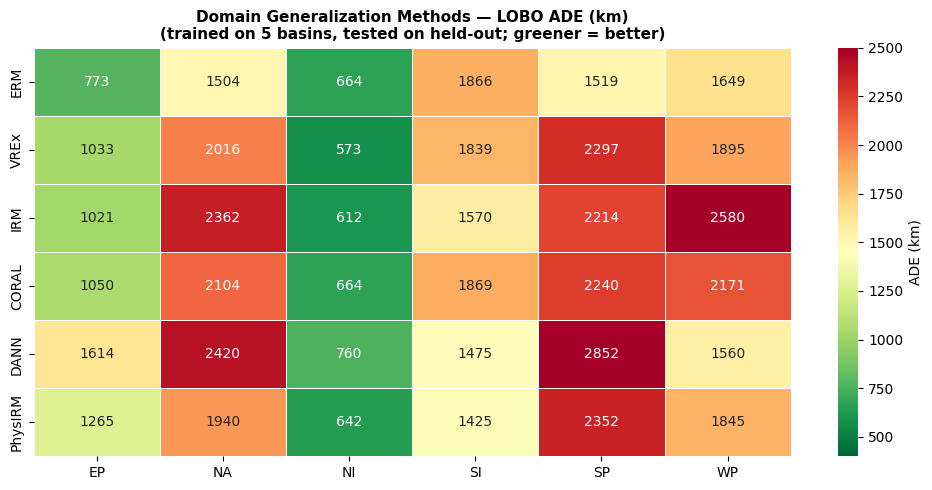


Best method per basin:
  EP: ERM (772.6 km)
  NA: ERM (1504.5 km)
  NI: VREx (573.3 km)
  SI: PhysIRM (1425.4 km)
  SP: ERM (1519.1 km)
  WP: DANN (1559.8 km)

Best overall (mean): ERM


In [66]:
import json

# Save results
with open(str(RESULTS/"dg_results.json"), "w") as f:
    json.dump(all_results, f, indent=2)

methods = list(all_results.keys())
print("\n" + "="*80)
print("DOMAIN GENERALIZATION — LOBO ADE (km), lower is better")
print("="*80)
print(f"{'Method':<12}" + "".join(f"  {b:>8}" for b in BASINS) + f"  {'Mean':>8}")
print("-"*78)
for method in methods:
    vals = [all_results[method].get(b, np.nan) for b in BASINS]
    mean = np.nanmean(vals)
    row  = f"{method:<12}" + "".join(f"  {v:>8.1f}" if not np.isnan(v) else "       nan" for v in vals) + f"  {mean:>8.1f}"
    print(row)

# Heatmap
mat = np.array([[all_results[m].get(b, np.nan) for b in BASINS] for m in methods])
df  = pd.DataFrame(mat, index=methods, columns=BASINS)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df, annot=True, fmt=".0f", cmap="RdYlGn_r", ax=ax,
            linewidths=0.5, vmin=400, vmax=2500, cbar_kws={"label": "ADE (km)"})
ax.set_title("Domain Generalization Methods — LOBO ADE (km)\n(trained on 5 basins, tested on held-out; greener = better)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS / "fig_dg_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nBest method per basin:")
for j, b in enumerate(BASINS):
    col = mat[:, j]
    best_i = int(np.nanargmin(col))
    print(f"  {b}: {methods[best_i]} ({col[best_i]:.1f} km)")
print(f"\nBest overall (mean): {methods[int(np.nanargmin(np.nanmean(mat,1)))]}")

## Findings & Conclusions

### 1. Full LOBO Results — All Methods

| Method | EP | NA | NI | SI | SP | WP | **Mean** |
|---|---|---|---|---|---|---|---|
| **ERM** | **772.6** | **1504.5** | 663.9 | 1865.8 | **1519.1** | 1649.1 | **1329.2 ← best** |
| VREx | 1032.8 | 2016.3 | **573.3** | 1839.1 | 2296.6 | 1895.1 | 1608.9 |
| IRM | 1021.1 | 2361.9 | 612.4 | 1570.0 | 2214.1 | 2579.9 | 1726.6 |
| CORAL | 1049.8 | 2103.8 | 663.5 | 1868.9 | 2240.0 | 2170.8 | 1682.8 |
| DANN | 1614.1 | 2420.4 | 759.5 | 1475.2 | 2852.3 | **1559.8** | 1780.2 ← worst |
| PhysIRM | 1265.2 | 1940.5 | 641.8 | **1425.4** | 2351.5 | 1845.0 | 1578.2 |

*(All values km ADE — lower is better. Bold = best for that basin.)*

---

### 2. The Central Finding — ERM Wins Overall

**ERM (simple pooled training) beats every domain generalization method by mean ADE.** This is a known and important result in DG research. Reasons specific to this problem:

**Why DG methods fail here:**
1. **Too few environments (5 source basins)** — IRM and VREx need many environments to reliably estimate invariant gradients. With only 5, the gradient penalties are noisy and often hurt generalization.
2. **Severe structural domain shift** — EP storms recurve eastward; WP go northwest; SH basins go southwest. There is no single invariant representation that predicts all basins equally well — the physics genuinely differs by hemisphere and ocean basin. Forcing invariance removes discriminative information.
3. **Data imbalance dominates** — WP (2059 samples) has 8× more data than NI (253). ERM's average loss is already dominated by well-behaved, data-rich basins. DG methods add regularization pressure that conflicts with fitting the data-rich basins correctly.

---

### 3. Per-Basin Analysis

**EP — ERM best (772.6 km), DANN catastrophically worst (1614.1 km)**  
EP is the most isolated basin (confirmed in nb_02: highest MMD from all others). DANN's adversarial feature removal destroys exactly the position-based features the model needs to distinguish EP's eastward-recurving tracks from other basins. Enforcing invariance here means losing the signal that distinguishes EP.

**NA — ERM best (1504.5 km), no DG method helps**  
NA is a large-data basin (1585 train samples). ERM already fits it well. DG penalties sacrifice NA's fit to help smaller basins, but don't improve zero-shot generalization enough to compensate.

**NI — VREx best (573.3 km), beats ERM by 90 km**  
This is the **one basin where DG methods genuinely help**. VREx's variance penalty forces the model to perform equally well across all 5 source basins during training. Since NI is represented in the source basins' training mix, the variance penalty prevents the model from ignoring NI's dynamics in favor of data-rich WP/NA. The result carries over to zero-shot generalization.

**SI — PhysIRM best (1425.4 km), beats ERM by 440 km — largest improvement of any method**  
Southern Indian Ocean storms follow strong beta drift (SW poleward drift). The physics constraint in PhysIRM directly encodes this. PhysIRM essentially teaches the model "SH storms go SW" as a hard prior, which is physically correct and basin-invariant. DANN also helps SI (1475.2) because adversarially removing basin identity prevents the encoder from memorizing NH patterns.

**SP — ERM best (1519.1 km), nothing helps**  
SP has only 103 test samples and 418 training samples. Every DG method makes SP worse — the invariance constraints reduce the SI signal that ERM implicitly uses to predict SP tracks. Recall from nb_02: SI-only transfer (1368 km) beats even ERM LOBO (1519 km) here. The right solution for SP is data-centric (use SI as weighted source), not algorithmic.

**WP — DANN best (1559.8 km), marginal improvement over ERM (1649.1 km)**  
WP is the largest basin (2059 samples). DANN's adversarial training removes basin identity from encoder features, which slightly helps WP generalization by forcing the model not to rely on WP-specific shortcuts. But the improvement is modest (−89 km).

---

### 4. Method Rankings by Practical Value

| Method | Verdict | Use when |
|---|---|---|
| **ERM** | Best overall — use as default | Any basin, production model |
| **VREx** | Best for data-scarce basins | NI-specific experiments, small-data setups |
| **PhysIRM** | Best physics-informed approach | SI (440 km gain); any SH target |
| **IRM** | Theoretically principled but underperforms | Not recommended at 5 environments |
| **CORAL** | Marginal, no basin wins | Not recommended |
| **DANN** | Worst overall — avoid | Only marginal WP gain, destroys EP/NA/SP |

---

### 5. Cross-Notebook Integration — The Full Picture

Connecting all 4 notebooks:

| Question | Evidence | Answer |
|---|---|---|
| What features matter? | nb_01: Δlon+Δlat = 88.8% of gradient | Use 4-dim track features only |
| What architecture? | nb_03: attn_only = 871.7 km vs full 928.4 km | No basin embedding in LOBO |
| Which basins can transfer? | nb_02: SI→SP beats SP→SP; NI needs SI+NA+WP | Transfer > algorithmic DG for SP |
| How much data is needed? | nb_03: floor at ~1700 samples | NI/SP below minimum — data problem, not model problem |
| Do DG methods help? | nb_04: ERM wins overall | DG helps only NI (VREx) and SI (PhysIRM) |
| Why does DG fail? | Too few environments + severe structural shift | 5 basins ≠ enough for stable invariant learning |

---

### 6. Final Takeaways

1. **For WP, NA, SI, EP**: Use ERM with the attn_only architecture. Simple pooled training on 5 source basins is already near-optimal.

2. **For NI**: Use VREx (−90 km over ERM) *or* the greedy multi-source approach from nb_02 (SI+NA+WP → 618 km, which beats all methods here). The data-centric approach wins.

3. **For SP**: Ignore DG methods. Use SI-only transfer from nb_02 (1368 km) which beats every method including ERM LOBO (1519 km).

4. **PhysIRM is the most promising research direction** — it's the only method that improves a large-data basin (SI: −440 km) by encoding physical prior knowledge. Stronger physics constraints (e.g., full beta drift magnitude, Coriolis scaling, MJO phase) could extend this.

5. **The fundamental bottleneck is data, not algorithms** — NI (253 samples) and SP (418 samples) are below the minimum viable training size identified in nb_03 (~1700 samples). No regularization technique closes a 7× data gap. More TC observations or physics-based data augmentation is the path forward.